In [6]:
import warnings
warnings.filterwarnings("ignore", module=r"matplotlib\..*")

In [7]:
# Učitavanje movie.csv 
import os
import numpy as np
import pandas as pd

relpath = '..\\data\\movie.csv'
abspath = os.path.abspath(relpath)

try:
    df = pd.read_csv(relpath)
except FileNotFoundError:
    df = pd.read_csv(abspath)

print("Dataset učitan:", df.shape)
df.head()

Dataset učitan: (40000, 2)


,text,label
0,I grew up (b. 1965) watching and loving the Th...,0
1,"When I put this movie in my DVD player, and sa...",0
2,Why do people who do not know what a particula...,0
3,Even though I have great interest in Biblical ...,0
4,Im a die hard Dads Army fan and nothing will e...,1


## Ucitavanje podataka

In [8]:
%matplotlib inline
import matplotlib.pyplot as plt
import seaborn as sns

In [9]:
df.describe()


,label
count,40000.000000
mean,0.499525
std,0.500006
min,0.000000
25%,0.000000
50%,0.000000
75%,1.000000
max,1.000000


In [10]:
import pandas as pd
from sklearn.model_selection import train_test_split

df = df.dropna(subset=["text", "label"]).copy()

df["text"] = df["text"].astype(str).str.strip()
df = df[df["text"] != ""].copy()

unknown = df["label"].isna().sum()
if unknown > 0:
    print(f"Upozorenje: uklonjeno {unknown} redova sa nepoznatom labelom.")
df = df.dropna(subset=["label"]).copy()
df["label"] = df["label"].astype(int)

df = df.drop_duplicates(subset=["text"]).reset_index(drop=True)

print("Shape:", df.shape)
print("\nClass distribution:")
print(df["label"].value_counts(normalize=True).rename("ratio"))

X_temp, X_test, y_temp, y_test = train_test_split(
    df["text"], df["label"], test_size=0.15, random_state=42, stratify=df["label"]
)
X_train, X_val, y_train, y_val = train_test_split(
    X_temp, y_temp, test_size=0.1765, random_state=42, stratify=y_temp
)

print("\nSplit sizes:")
print(f"Train: {len(X_train)}")
print(f"Val:   {len(X_val)}")
print(f"Test:  {len(X_test)}")

Shape: (39723, 2)

Class distribution:
label
1    0.501171
0    0.498829
Name: ratio, dtype: float64

Split sizes:
Train: 27804
Val:   5960
Test:  5959


In [11]:
#%pip install -q tensorflow

import numpy as np
import tensorflow as tf
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences

# Reproducibility
tf.random.set_seed(42)
np.random.seed(42)

# Hyperparameters
VOCAB_SIZE = 20000
MAX_LEN = 200
OOV_TOKEN = "<OOV>"

# Keras Tokenizer
tokenizer = Tokenizer(num_words=VOCAB_SIZE, oov_token=OOV_TOKEN)
tokenizer.fit_on_texts(X_train)

# Convert text -> sequences
train_seq = tokenizer.texts_to_sequences(X_train)
val_seq   = tokenizer.texts_to_sequences(X_val)
test_seq  = tokenizer.texts_to_sequences(X_test)

# Pad sequences
X_train_pad = pad_sequences(train_seq, maxlen=MAX_LEN, padding="post", truncating="post")
X_val_pad   = pad_sequences(val_seq,   maxlen=MAX_LEN, padding="post", truncating="post")
X_test_pad  = pad_sequences(test_seq,  maxlen=MAX_LEN, padding="post", truncating="post")

y_train_np = np.array(y_train)
y_val_np   = np.array(y_val)
y_test_np  = np.array(y_test)

print("Train padded shape:", X_train_pad.shape)
print("Val padded shape:", X_val_pad.shape)
print("Test padded shape:", X_test_pad.shape)

Train padded shape: (27804, 200)
Val padded shape: (5960, 200)
Test padded shape: (5959, 200)


Primer tokenizacije iz train seta:
   label                                                                                                                text_preview                                                                                    seq_preview                                                                                                                               tokens_preview  n_tokens
negative this is the worst film i have ever seen and what disappoints me the most is that this is yash raj film so at first when ...            [12, 7, 2, 246, 20, 11, 26, 124, 107, 3, 49, 12311, 69, 2, 89, 7, 13, 12, 7, 14191]                           [this, is, the, worst, film, i, have, ever, seen, and, what, disappoints, me, the, most, is, that, this, is, yash]       144
positive I wanted to see Sarah Buffy on the big screen, so I first bought tickets and then checked the reviews at IMDb. I worried...     [11, 453, 6, 64, 2472, 7737, 21, 2, 188, 264, 36, 11, 88, 1202, 6296, 

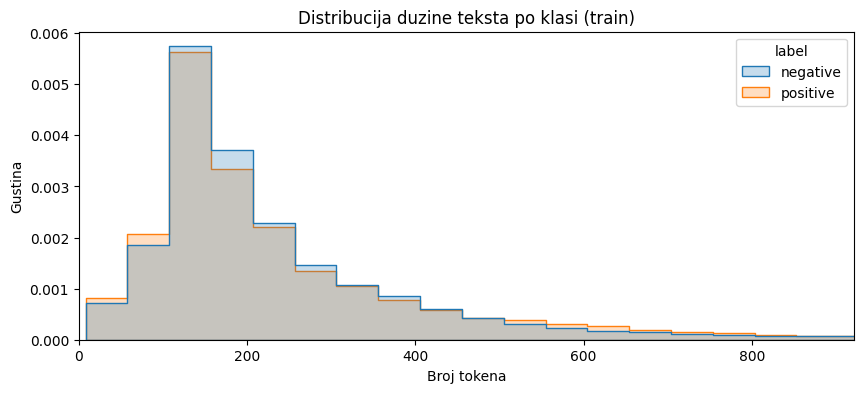


Najcesci tokeni u negative klasi:
token  count    share
  the 179774 0.057440
    a  87408 0.027928
  and  81275 0.025969
   of  75508 0.024126
   to  75183 0.024022
   br  57812 0.018472
   is  54877 0.017534
   in  47892 0.015302
    i  44941 0.014359
 this  44837 0.014326
   it  43347 0.013850
 that  38947 0.012444
  was  28910 0.009237
movie  27264 0.008711
  for  23872 0.007627

Najcesci tokeni u positive klasi:
token  count    share
  the 192822 0.059450
  and  99447 0.030661
    a  92787 0.028608
   of  86150 0.026561
   to  74343 0.022921
   is  63111 0.019458
   in  56427 0.017397
   br  55516 0.017116
   it  43992 0.013563
    i  41291 0.012731
 this  39089 0.012052
 that  37743 0.011637
   as  28963 0.008930
 with  25610 0.007896
  for  25144 0.007752


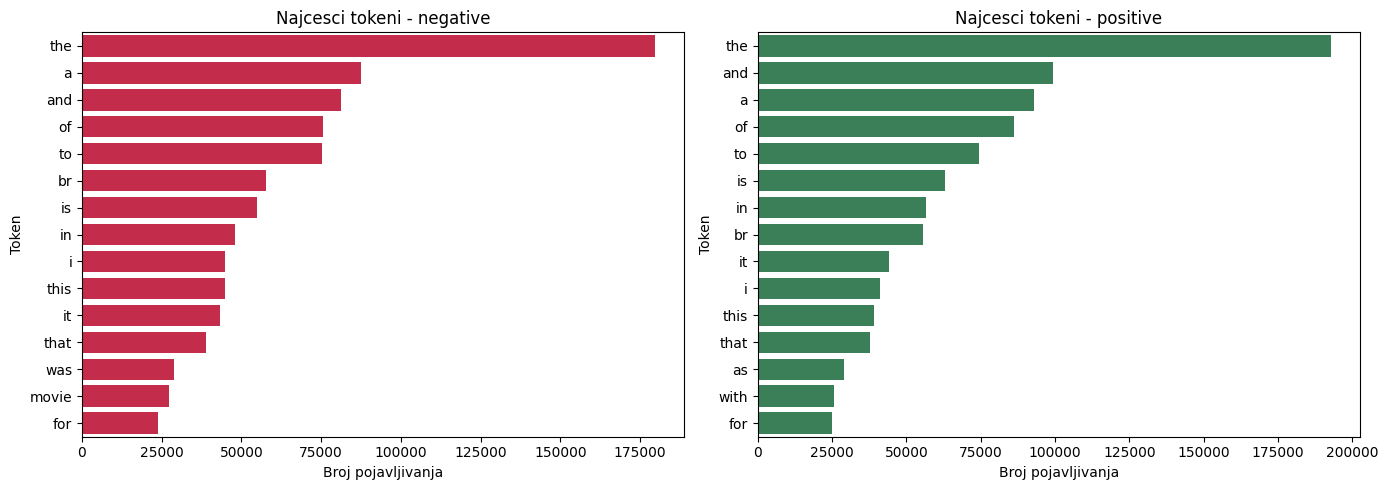


Tokeni karakteristicniji za negative klasu:
token  neg_count  pos_count  freq_diff
 this      44837      39089  -0.002274
movie      27264      21150  -0.002190
  bad       7988       2123  -0.001898
  was      28910      24542  -0.001670
    i      44941      41291  -0.001629
   br      57812      55516  -0.001355
 just      11580       7921  -0.001258
   no       8965       5231  -0.001252
 have      17010      13875  -0.001157
   to      75183      74343  -0.001101
 even       8500       5418  -0.001045
 they      13067      10151  -0.001045
   or      11230       8687  -0.000910
 like      12370       9905  -0.000899
   if      10548       8250  -0.000827

Tokeni karakteristicniji za positive klasu:
token  neg_count  pos_count  freq_diff
  and      81275      99447   0.004693
   of      75508      86150   0.002436
   in      47892      56427   0.002095
  the     179774     192822   0.002010
   is      54877      63111   0.001924
  his      13012      19176   0.001755
   as      22

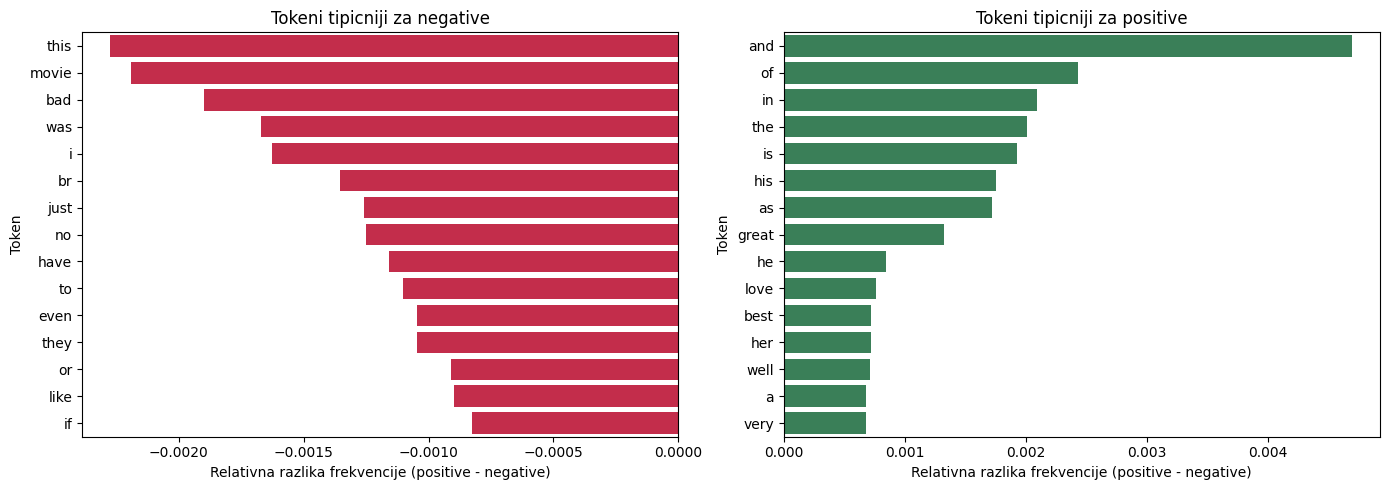

In [22]:
from collections import Counter

# Mapa: token_id -> rec
index_to_word = {idx: word for word, idx in tokenizer.word_index.items()}

def decode_tokens(seq, limit=20):
    return [index_to_word.get(tok, OOV_TOKEN if tok == 1 else f"<{tok}>") for tok in seq[:limit]]

def short_text(text, limit=120):
    text = str(text).replace("\n", " ").strip()
    return text[:limit] + ("..." if len(text) > limit else "")

# 1) Primeri kako je tekst tokenizovan
sample_idx = [0, 1, 2, 3, 4]
sample_token_df = pd.DataFrame({
    "label": ["positive" if y_train_np[i] == 1 else "negative" for i in sample_idx],
    "text_preview": [short_text(X_train.iloc[i]) for i in sample_idx],
    "seq_preview": [train_seq[i][:20] for i in sample_idx],
    "tokens_preview": [decode_tokens(train_seq[i], 20) for i in sample_idx],
    "n_tokens": [len(train_seq[i]) for i in sample_idx]
})

print("Primer tokenizacije iz train seta:")
print(sample_token_df.to_string(index=False))

# 2) Analiza duzine teksta
train_lengths = np.array([len(seq) for seq in train_seq])
length_df = pd.DataFrame({
    "label": np.where(y_train_np == 1, "positive", "negative"),
    "n_tokens": train_lengths
})

print("\nStatistika duzine review-a po klasi:")
print(length_df.groupby("label")["n_tokens"].describe().round(2))

plt.figure(figsize=(10, 4))
sns.histplot(
    data=length_df,
    x="n_tokens",
    hue="label",
    bins=50,
    stat="density",
    common_norm=False,
    element="step"
)
plt.xlim(0, np.percentile(train_lengths, 99))
plt.title("Distribucija duzine teksta po klasi (train)")
plt.xlabel("Broj tokena")
plt.ylabel("Gustina")
plt.show()

# 3) Najcesci tokeni po klasi
neg_counter = Counter()
pos_counter = Counter()

for seq, label in zip(train_seq, y_train_np):
    valid_seq = [tok for tok in seq if 1 < tok < VOCAB_SIZE]  # izbacuje OOV
    if label == 0:
        neg_counter.update(valid_seq)
    else:
        pos_counter.update(valid_seq)

def top_tokens_df(counter, top_n=15):
    total = sum(counter.values())
    rows = []
    for tok_id, cnt in counter.most_common(top_n):
        rows.append({
            "token_id": tok_id,
            "token": index_to_word.get(tok_id, "<UNK>"),
            "count": cnt,
            "share": cnt / total
        })
    return pd.DataFrame(rows)

top_neg = top_tokens_df(neg_counter, top_n=15)
top_pos = top_tokens_df(pos_counter, top_n=15)

print("\nNajcesci tokeni u negative klasi:")
print(top_neg[["token", "count", "share"]].to_string(index=False))

print("\nNajcesci tokeni u positive klasi:")
print(top_pos[["token", "count", "share"]].to_string(index=False))

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.barplot(data=top_neg, x="count", y="token", color="crimson", ax=axes[0])
axes[0].set_title("Najcesci tokeni - negative")
axes[0].set_xlabel("Broj pojavljivanja")
axes[0].set_ylabel("Token")

sns.barplot(data=top_pos, x="count", y="token", color="seagreen", ax=axes[1])
axes[1].set_title("Najcesci tokeni - positive")
axes[1].set_xlabel("Broj pojavljivanja")
axes[1].set_ylabel("Token")

plt.tight_layout()
plt.show()

# 4) Tokeni koji su karakteristicniji za jednu od dve klase
neg_total = sum(neg_counter.values())
pos_total = sum(pos_counter.values())

rows = []
all_tok_ids = set(neg_counter.keys()) | set(pos_counter.keys())

for tok_id in all_tok_ids:
    neg_cnt = neg_counter[tok_id]
    pos_cnt = pos_counter[tok_id]
    total_cnt = neg_cnt + pos_cnt

    if total_cnt < 30:
        continue

    neg_freq = neg_cnt / neg_total
    pos_freq = pos_cnt / pos_total

    rows.append({
        "token_id": tok_id,
        "token": index_to_word.get(tok_id, "<UNK>"),
        "neg_count": neg_cnt,
        "pos_count": pos_cnt,
        "neg_freq": neg_freq,
        "pos_freq": pos_freq,
        "freq_diff": pos_freq - neg_freq,
        "total_count": total_cnt
    })

token_stats_df = pd.DataFrame(rows)

most_negative = token_stats_df.sort_values("freq_diff").head(15).copy()
most_positive = token_stats_df.sort_values("freq_diff", ascending=False).head(15).copy()

print("\nTokeni karakteristicniji za negative klasu:")
print(most_negative[["token", "neg_count", "pos_count", "freq_diff"]].to_string(index=False))

print("\nTokeni karakteristicniji za positive klasu:")
print(most_positive[["token", "neg_count", "pos_count", "freq_diff"]].to_string(index=False))

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.barplot(data=most_negative, x="freq_diff", y="token", color="crimson", ax=axes[0])
axes[0].set_title("Tokeni tipicniji za negative")
axes[0].set_xlabel("Relativna razlika frekvencije (positive - negative)")
axes[0].set_ylabel("Token")

sns.barplot(data=most_positive, x="freq_diff", y="token", color="seagreen", ax=axes[1])
axes[1].set_title("Tokeni tipicniji za positive")
axes[1].set_xlabel("Relativna razlika frekvencije (positive - negative)")
axes[1].set_ylabel("Token")

plt.tight_layout()
plt.show()

In [12]:
from tensorflow.keras import layers, callbacks, models
from sklearn.utils.class_weight import compute_class_weight

classes = np.unique(y_train_np)
weights = compute_class_weight(class_weight="balanced", classes=classes, y=y_train_np)
class_weight = {int(c): float(w) for c, w in zip(classes, weights)}
print("Class weights:", class_weight)

model = models.Sequential([
    layers.Embedding(input_dim=VOCAB_SIZE, output_dim=128, input_length=MAX_LEN, mask_zero=True),
    layers.Bidirectional(layers.LSTM(64, return_sequences=False)),
    layers.Dropout(0.4),
    layers.Dense(64, activation="relu"),
    layers.Dropout(0.3),
    layers.Dense(1, activation="sigmoid")
])

model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=5e-4),
    loss="binary_crossentropy",
    metrics=["accuracy", tf.keras.metrics.Precision(name="precision"), tf.keras.metrics.Recall(name="recall")]
)

early_stop = callbacks.EarlyStopping(monitor="val_loss", patience=3, restore_best_weights=True)
reduce_lr = callbacks.ReduceLROnPlateau(monitor="val_loss", factor=0.5, patience=1, min_lr=1e-6, verbose=1)

history = model.fit(
    X_train_pad, y_train_np,
    validation_data=(X_val_pad, y_val_np),
    epochs=12,
    batch_size=64,
    class_weight=class_weight,
    callbacks=[early_stop, reduce_lr],
    verbose=1
)

Class weights: {0: 1.0023794073112697, 1: 0.9976318622174382}
Epoch 1/12


c:\Users\jelen\AppData\Local\Programs\Python\Python313\Lib\site-packages\keras\src\layers\core\embedding.py:100: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


435/435 ━━━━━━━━━━━━━━━━━━━━ 37s 79ms/step - accuracy: 0.7873 - loss: 0.4352 - precision: 0.7732 - recall: 0.8145 - val_accuracy: 0.8743 - val_loss: 0.3032 - val_precision: 0.8747 - val_recall: 0.8745 - learning_rate: 5.0000e-04
Epoch 2/12
435/435 ━━━━━━━━━━━━━━━━━━━━ 0s 78ms/step - accuracy: 0.8970 - loss: 0.2548 - precision: 0.8993 - recall: 0.8935
Epoch 2: ReduceLROnPlateau reducing learning rate to 0.0002500000118743628.
435/435 ━━━━━━━━━━━━━━━━━━━━ 36s 83ms/step - accuracy: 0.9140 - loss: 0.2229 - precision: 0.9169 - recall: 0.9109 - val_accuracy: 0.8659 - val_loss: 0.3329 - val_precision: 0.8791 - val_recall: 0.8493 - learning_rate: 5.0000e-04
Epoch 3/12
435/435 ━━━━━━━━━━━━━━━━━━━━ 0s 82ms/step - accuracy: 0.9442 - loss: 0.1574 - precision: 0.9472 - recall: 0.9405
Epoch 3: ReduceLROnPlateau reducing learning rate to 0.0001250000059371814.
435/435 ━━━━━━━━━━━━━━━━━━━━ 38s 87ms/step - accuracy: 0.9546 - loss: 0.1316 - precision: 0.9573 - recall: 0.9519 - val_accuracy: 0.8669 - val

In [13]:
from sklearn.metrics import classification_report, confusion_matrix, f1_score

test_loss, test_acc, test_prec, test_rec = model.evaluate(X_test_pad, y_test_np, verbose=0)
y_prob = model.predict(X_test_pad, verbose=0).ravel()
y_pred = (y_prob >= 0.5).astype(int)

print(f"Test Accuracy:  {test_acc:.4f}")
print(f"Test Precision: {test_prec:.4f}")
print(f"Test Recall:    {test_rec:.4f}")
print(f"Test F1:        {f1_score(y_test_np, y_pred):.4f}")

print("\nClassification report:")
print(classification_report(y_test_np, y_pred, digits=4))

print("Confusion matrix:")
print(confusion_matrix(y_test_np, y_pred))

Test Accuracy:  0.8663
Test Precision: 0.8604
Test Recall:    0.8751
Test F1:        0.8677

Classification report:
              precision    recall  f1-score   support

           0     0.8723    0.8574    0.8648      2973
           1     0.8604    0.8751    0.8677      2986

    accuracy                         0.8663      5959
   macro avg     0.8664    0.8662    0.8662      5959
weighted avg     0.8664    0.8663    0.8662      5959

Confusion matrix:
[[2549  424]
 [ 373 2613]]


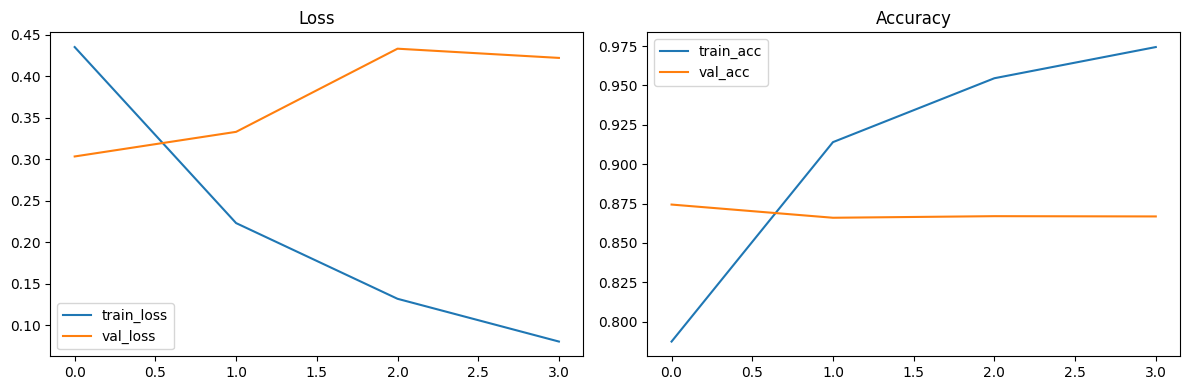

In [14]:
import matplotlib.pyplot as plt

# history from model.fit(...)
hist = history.history

plt.figure(figsize=(12,4))

plt.subplot(1,2,1)
plt.plot(hist["loss"], label="train_loss")
plt.plot(hist["val_loss"], label="val_loss")
plt.title("Loss")
plt.legend()

plt.subplot(1,2,2)
plt.plot(hist["accuracy"], label="train_acc")
plt.plot(hist["val_accuracy"], label="val_acc")
plt.title("Accuracy")
plt.legend()

plt.tight_layout()
plt.show()

In [15]:
import numpy as np
from sklearn.metrics import f1_score, precision_recall_curve, classification_report, confusion_matrix

# Validation probabilities
val_prob = model.predict(X_val_pad, verbose=0).ravel()

# Search threshold that maximizes F1 on validation
thresholds = np.linspace(0.1, 0.9, 81)
f1_scores = []

for t in thresholds:
    val_pred_t = (val_prob >= t).astype(int)
    f1_scores.append(f1_score(y_val_np, val_pred_t))

best_idx = int(np.argmax(f1_scores))
best_t = float(thresholds[best_idx])
best_f1 = float(f1_scores[best_idx])

print(f"Best threshold (val): {best_t:.3f}")
print(f"Best val F1:          {best_f1:.4f}")

Best threshold (val): 0.400
Best val F1:          0.8766


In [16]:
# Final test evaluation with tuned threshold
test_prob = model.predict(X_test_pad, verbose=0).ravel()
test_pred_tuned = (test_prob >= best_t).astype(int)

print(classification_report(y_test_np, test_pred_tuned, digits=4))
print("Confusion matrix:\n", confusion_matrix(y_test_np, test_pred_tuned))

              precision    recall  f1-score   support

           0     0.8853    0.8359    0.8599      2973
           1     0.8452    0.8922    0.8680      2986

    accuracy                         0.8641      5959
   macro avg     0.8652    0.8640    0.8639      5959
weighted avg     0.8652    0.8641    0.8640      5959

Confusion matrix:
 [[2485  488]
 [ 322 2664]]


In [17]:
import numpy as np
import tensorflow as tf
from tensorflow.keras import layers, models, callbacks
from sklearn.metrics import f1_score

tf.random.set_seed(42)
np.random.seed(42)

def build_bigru(vocab_size, max_len, emb_dim=128, gru_units=64, drop=0.4, lr=1e-3):
    model = models.Sequential([
        layers.Embedding(input_dim=vocab_size, output_dim=emb_dim, input_length=max_len, mask_zero=True),
        layers.Bidirectional(layers.GRU(gru_units)),
        layers.Dropout(drop),
        layers.Dense(64, activation="relu"),
        layers.Dropout(0.3),
        layers.Dense(1, activation="sigmoid")
    ])
    model.compile(
        optimizer=tf.keras.optimizers.Adam(learning_rate=lr),
        loss="binary_crossentropy",
        metrics=["accuracy"]
    )
    return model

configs = [
    {"emb_dim": 128, "gru_units": 64,  "drop": 0.4, "lr": 1e-3, "batch_size": 64},
    {"emb_dim": 128, "gru_units": 128, "drop": 0.4, "lr": 1e-3, "batch_size": 64},
    {"emb_dim": 256, "gru_units": 64,  "drop": 0.5, "lr": 5e-4, "batch_size": 64},
]

best = {"f1": -1, "cfg": None, "model": None, "thr": 0.5}

for i, cfg in enumerate(configs, 1):
    print(f"\n=== Config {i}/{len(configs)}: {cfg} ===")
    m = build_bigru(VOCAB_SIZE, MAX_LEN, **{k: cfg[k] for k in ["emb_dim", "gru_units", "drop", "lr"]})
    es = callbacks.EarlyStopping(monitor="val_loss", patience=2, restore_best_weights=True)
    rlr = callbacks.ReduceLROnPlateau(monitor="val_loss", factor=0.5, patience=1, min_lr=1e-6, verbose=0)
    
    m.fit(
        X_train_pad, y_train_np,
        validation_data=(X_val_pad, y_val_np),
        epochs=8,
        batch_size=cfg["batch_size"],
        class_weight=class_weight,
        callbacks=[es, rlr],
        verbose=0
    )

    val_prob = m.predict(X_val_pad, verbose=0).ravel()
    thrs = np.linspace(0.2, 0.8, 61)
    f1s = [f1_score(y_val_np, (val_prob >= t).astype(int)) for t in thrs]
    idx = int(np.argmax(f1s))
    f1_best = float(f1s[idx])
    thr_best = float(thrs[idx])

    print(f"Val best F1={f1_best:.4f} at threshold={thr_best:.3f}")

    if f1_best > best["f1"]:
        best = {"f1": f1_best, "cfg": cfg, "model": m, "thr": thr_best}

print("\nBest config:", best["cfg"])
print("Best val F1:", round(best["f1"], 4), "Threshold:", round(best["thr"], 3))
best_model = best["model"]
best_t = best["thr"]


=== Config 1/3: {'emb_dim': 128, 'gru_units': 64, 'drop': 0.4, 'lr': 0.001, 'batch_size': 64} ===


c:\Users\jelen\AppData\Local\Programs\Python\Python313\Lib\site-packages\keras\src\layers\core\embedding.py:100: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


Val best F1=0.8752 at threshold=0.430

=== Config 2/3: {'emb_dim': 128, 'gru_units': 128, 'drop': 0.4, 'lr': 0.001, 'batch_size': 64} ===


c:\Users\jelen\AppData\Local\Programs\Python\Python313\Lib\site-packages\keras\src\layers\core\embedding.py:100: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


Val best F1=0.8779 at threshold=0.380

=== Config 3/3: {'emb_dim': 256, 'gru_units': 64, 'drop': 0.5, 'lr': 0.0005, 'batch_size': 64} ===


c:\Users\jelen\AppData\Local\Programs\Python\Python313\Lib\site-packages\keras\src\layers\core\embedding.py:100: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


Val best F1=0.8784 at threshold=0.330

Best config: {'emb_dim': 256, 'gru_units': 64, 'drop': 0.5, 'lr': 0.0005, 'batch_size': 64}
Best val F1: 0.8784 Threshold: 0.33


In [18]:
from sklearn.metrics import classification_report, confusion_matrix, f1_score

test_prob = best_model.predict(X_test_pad, verbose=0).ravel()
test_pred = (test_prob >= best_t).astype(int)

print("Test F1:", round(f1_score(y_test_np, test_pred), 4))
print(classification_report(y_test_np, test_pred, digits=4))
print("Confusion matrix:\n", confusion_matrix(y_test_np, test_pred))

Test F1: 0.8674
              precision    recall  f1-score   support

           0     0.9002    0.8103    0.8529      2973
           1     0.8282    0.9106    0.8674      2986

    accuracy                         0.8605      5959
   macro avg     0.8642    0.8604    0.8602      5959
weighted avg     0.8641    0.8605    0.8602      5959

Confusion matrix:
 [[2409  564]
 [ 267 2719]]


In [19]:
from pathlib import Path
import json

# Create artifact folder
ARTIFACT_DIR = Path("../artifacts")
ARTIFACT_DIR.mkdir(parents=True, exist_ok=True)

# Save best model
best_model_path = ARTIFACT_DIR / "sentiment_bigru.keras"
best_model.save(best_model_path)

# Save tokenizer as JSON
tokenizer_json = tokenizer.to_json()
with open(ARTIFACT_DIR / "tokenizer.json", "w", encoding="utf-8") as f:
    f.write(tokenizer_json)

# Save metadata (must match training)
meta = {
    "max_len": MAX_LEN,
    "vocab_size": VOCAB_SIZE,
    "oov_token": OOV_TOKEN,
    "best_threshold": float(best_t),
    "label_map_out": {0: "negative", 1: "positive"}
}
with open(ARTIFACT_DIR / "meta.json", "w", encoding="utf-8") as f:
    json.dump(meta, f, ensure_ascii=False, indent=2)

print("Saved:")
print("-", best_model_path.resolve())
print("-", (ARTIFACT_DIR / "tokenizer.json").resolve())
print("-", (ARTIFACT_DIR / "meta.json").resolve())

Saved:
- C:\Users\jelen\OneDrive\Documents\_Master\Masinsko ucenje\Git\GIT - Anastasija - Projekat\machine-learning\artifacts\sentiment_bigru.keras
- C:\Users\jelen\OneDrive\Documents\_Master\Masinsko ucenje\Git\GIT - Anastasija - Projekat\machine-learning\artifacts\tokenizer.json
- C:\Users\jelen\OneDrive\Documents\_Master\Masinsko ucenje\Git\GIT - Anastasija - Projekat\machine-learning\artifacts\meta.json


In [20]:
import json
import numpy as np
import tensorflow as tf
from pathlib import Path
from tensorflow.keras.preprocessing.text import tokenizer_from_json
from tensorflow.keras.preprocessing.sequence import pad_sequences

ARTIFACT_DIR = Path("../artifacts")

# Load model
loaded_model = tf.keras.models.load_model(ARTIFACT_DIR / "sentiment_bigru.keras")

# Load tokenizer
with open(ARTIFACT_DIR / "tokenizer.json", "r", encoding="utf-8") as f:
    loaded_tokenizer = tokenizer_from_json(f.read())

# Load metadata
with open(ARTIFACT_DIR / "meta.json", "r", encoding="utf-8") as f:
    loaded_meta = json.load(f)

loaded_max_len = int(loaded_meta["max_len"])
loaded_thr = float(loaded_meta["best_threshold"])

def predict_sentiment(text: str):
    seq = loaded_tokenizer.texts_to_sequences([text])
    pad = pad_sequences(seq, maxlen=loaded_max_len, padding="post", truncating="post")
    prob = float(loaded_model.predict(pad, verbose=0).ravel()[0])
    pred = int(prob >= loaded_thr)
    label = "positive" if pred == 1 else "negative"
    return {"text": text, "prob_positive": prob, "threshold": loaded_thr, "pred_label": label}

# Quick test
print(predict_sentiment("This movie was amazing, I loved it."))
print(predict_sentiment("Terrible film, boring and too long."))

{'text': 'This movie was amazing, I loved it.', 'prob_positive': 0.9380736351013184, 'threshold': 0.33000000000000007, 'pred_label': 'positive'}
{'text': 'Terrible film, boring and too long.', 'prob_positive': 0.028081821277737617, 'threshold': 0.33000000000000007, 'pred_label': 'negative'}


In [21]:
import numpy as np
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix

# Koristi best_model ako postoji, inače model
final_model = best_model if "best_model" in globals() else model
final_thr = best_t if "best_t" in globals() else 0.5
final_cfg = best["cfg"] if "best" in globals() and isinstance(best, dict) and "cfg" in best else "BiLSTM baseline"

# Predikcija
test_prob = final_model.predict(X_test_pad, verbose=0).ravel()
test_pred = (test_prob >= final_thr).astype(int)

# Metrike
acc = accuracy_score(y_test_np, test_pred)
prec = precision_score(y_test_np, test_pred, zero_division=0)
rec = recall_score(y_test_np, test_pred, zero_division=0)
f1 = f1_score(y_test_np, test_pred, zero_division=0)
cm = confusion_matrix(y_test_np, test_pred)
tn, fp, fn, tp = cm.ravel()

report_text = f"""
## Rezultati i diskusija

U radu je primenjena binarna klasifikacija sentimenta komentara filmova (`negative=0`, `positive=1`).
Podaci su očišćeni (prazni zapisi, duplikati), labele normalizovane na 0/1 i izvršena je stratifikovana podela 70/15/15 (train/validation/test).

Kao modeli korišćene su neuronske mreže nad tokenizovanim i padovanim sekvencama teksta, uz EarlyStopping i optimizaciju praga odlučivanja na validacionom skupu.

Najbolja konfiguracija modela:
- **Model/konfiguracija:** {final_cfg}
- **Optimalni threshold (validation):** {final_thr:.3f}

Rezultati na test skupu:
- **Accuracy:** {acc:.4f}
- **Precision:** {prec:.4f}
- **Recall:** {rec:.4f}
- **F1-score:** {f1:.4f}

Matrica konfuzije:
- **TN:** {tn}
- **FP:** {fp}
- **FN:** {fn}
- **TP:** {tp}

Zaključak: model pokazuje dobru sposobnost razlikovanja pozitivnih i negativnih komentara.
Dalje unapređenje je moguće kroz Transformer fine-tuning (npr. DistilBERT/BERT za engleski), dodatni tuning hiperparametara i detaljniju analizu FP/FN slučajeva.
"""

print(report_text)


## Rezultati i diskusija

U radu je primenjena binarna klasifikacija sentimenta komentara filmova (`negative=0`, `positive=1`).
Podaci su očišćeni (prazni zapisi, duplikati), labele normalizovane na 0/1 i izvršena je stratifikovana podela 70/15/15 (train/validation/test).

Kao modeli korišćene su neuronske mreže nad tokenizovanim i padovanim sekvencama teksta, uz EarlyStopping i optimizaciju praga odlučivanja na validacionom skupu.

Najbolja konfiguracija modela:
- **Model/konfiguracija:** {'emb_dim': 256, 'gru_units': 64, 'drop': 0.5, 'lr': 0.0005, 'batch_size': 64}
- **Optimalni threshold (validation):** 0.330

Rezultati na test skupu:
- **Accuracy:** 0.8605
- **Precision:** 0.8282
- **Recall:** 0.9106
- **F1-score:** 0.8674

Matrica konfuzije:
- **TN:** 2409
- **FP:** 564
- **FN:** 267
- **TP:** 2719

Zaključak: model pokazuje dobru sposobnost razlikovanja pozitivnih i negativnih komentara.
Dalje unapređenje je moguće kroz Transformer fine-tuning (npr. DistilBERT/BERT za engleski),